<div style="background-color: #f8f9fa; padding: 25px; border-radius: 10px; border-left: 6px solid #1a365d; box-shadow: 0 4px 6px rgba(0,0,0,0.05);">
    <h1 style="color: #1a365d; margin-bottom: 5px; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">Data Science Assignment 3</h1>
    <h3 style="color: #4a5568; margin-top: 0; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;">University of Tehran - Spring 2026</h3>
    <hr style="border: 1px solid #e2e8f0;">
    <p style="font-size: 16px; color: #2d3748;">
        <b>Course:</b> Introduction to Data Science <br><br>
        <b>🧑‍💻 Implementer:</b> Parsa Saeednia <br>
        <b>🆔 Student ID:</b> 810102460 <br><br>
        <h5 style="color: #1a365d;"> TASK 3 Implementation</h5>
    </p>
</div>

<div class="alert alert-info" style="border-left: 4px solid #3182ce; background-color: #ebf8ff; color: #2b6cb0;">
    <strong>💡 Project Overview:</strong> 
    This notebook contains the programmatic implementation for Assignment 3 - Task 3. It focuses on <b>ranking candidates for job positions</b> using traditional machine learning techniques. The implementation follows a complete ML workflow, including data exploration, preprocessing, feature engineering, model selection, evaluation, and final CSV submission generation for the Quera competition.
</div>

## Table of Contents
1. [Data Exploration & Understanding](#exploration)
2. [Preprocessing & Feature Engineering](#preprocessing)
3. [Model Development & Selection](#modeling)
4. [Comprehensive Evaluation](#evaluation)
5. [Prediction & Final Submission](#submission)

<a id="exploration"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">1. Data Exploration & Understanding</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> In this section, we load the candidate ranking dataset and perform Exploratory Data Analysis (EDA) to investigate the relationships between candidate features and their respective rankings. 
</div>

## 

### Importing Libraries & Loading Data

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style for better scannability
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load the datasets
jobs_df = pd.read_csv('data/task3_dataset/jobs.csv')
candidates_df = pd.read_csv('data/task3_dataset/candidates.csv')
train_df = pd.read_csv('data/task3_dataset/applications_train.csv')
test_df = pd.read_csv('data/task3_dataset/applications_test.csv')

print(f"Jobs Data: {jobs_df.shape}")
print(f"Candidates Data: {candidates_df.shape}")
print(f"Train Applications: {train_df.shape}")
print(f"Test Applications: {test_df.shape}")

Jobs Data: (5000, 13)
Candidates Data: (50000, 14)
Train Applications: (118772, 5)
Test Applications: (52700, 4)


### Initial Data Inspection & Missing Values Summary

In [45]:
# Create a quick summary dataframe for missing values
def missing_values_summary(df, name):
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    summary = pd.DataFrame({'Missing Values': missing, 'Percentage (%)': missing_percent})
    print(f"\n--- {name} Missing Values ---")
    display(summary[summary['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False))

missing_values_summary(jobs_df, "Jobs")
missing_values_summary(candidates_df, "Candidates")
missing_values_summary(train_df, "Training Applications")


--- Jobs Missing Values ---


,Missing Values,Percentage (%)
max_years_experience,495,9.90
company_size,377,7.54
remote_allowed,265,5.30
required_skills,248,4.96
min_years_experience,105,2.10



--- Candidates Missing Values ---


,Missing Values,Percentage (%)
certifications,28179,56.358
previous_companies,13465,26.930
university,12338,24.676
willing_to_relocate,7707,15.414
english_proficiency,5129,10.258
years_experience,4041,8.082



--- Training Applications Missing Values ---


,Missing Values,Percentage (%)


### Target Variable Distribution (Relevance Labels)

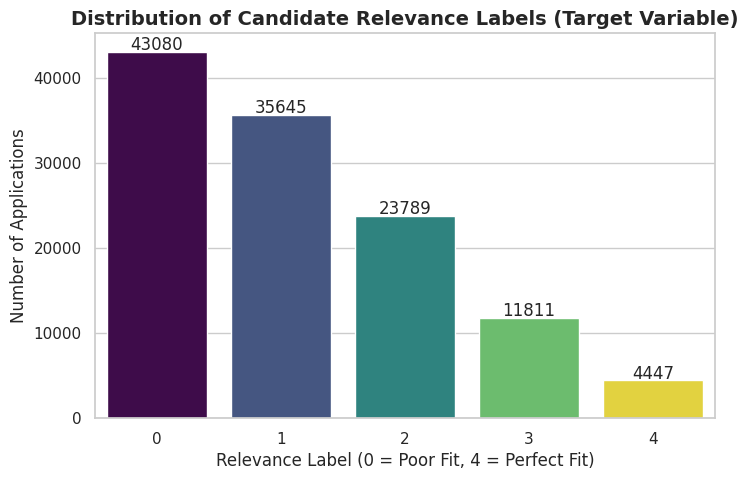

In [46]:
# Analyze the distribution of the relevance labels in the training set
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='relevance_label', data=train_df, hue='relevance_label', palette='viridis', legend=False)
plt.title('Distribution of Candidate Relevance Labels (Target Variable)', fontsize=14, fontweight='bold')
plt.xlabel('Relevance Label (0 = Poor Fit, 4 = Perfect Fit)')
plt.ylabel('Number of Applications')
plt.savefig('latex/assets/images/01_target_distribution.png', bbox_inches='tight', dpi=300)
# Add exact counts on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()

### Merging Data for Contextual Exploration

In [47]:
# To see how features relate to the label, we need to temporarily merge the data
eda_df = train_df.merge(jobs_df, on='job_id', how='left')
eda_df = eda_df.merge(candidates_df, on='candidate_id', how='left')

print("Merged EDA DataFrame Shape:", eda_df.shape)
display(eda_df.head(3))

Merged EDA DataFrame Shape: (118772, 30)


,application_id,job_id,candidate_id,application_date,relevance_label,job_title,required_skills,min_years_experience,max_years_experience,salary_min,...,education_level,university,previous_companies,certifications,english_proficiency,expected_salary,candidate_location,willing_to_relocate,profile_completeness,account_created_date
0,206,6,31050,2023-11-26,2,Web Developer,CSS|Django|Tailwind|JavaScript|Testing,4.0,10.0,2520000000,...,Master,Generic State University 27,Generic Tech Co 18|Stripe|Generic Tech Co 52|G...,Azure-AZ305,NaN,116655.275330,Istanbul,NaN,89,2023-01-07
1,207,6,19239,2023-11-16,1,Web Developer,CSS|Django|Tailwind|JavaScript|Testing,4.0,10.0,2520000000,...,PhD,Online University A,Generic Tech Co 24|Generic Tech Co 56|Generic ...,NaN,C1,86966.039783,London,NaN,88,2020-07-29
2,208,6,34280,2023-11-26,2,Web Developer,CSS|Django|Tailwind|JavaScript|Testing,4.0,10.0,2520000000,...,Bachelor,NaN,NaN,NaN,B1,91955.832040,Berlin,No,64,2022-05-19


### Investigating the Currency Trap & Experience Anomalies

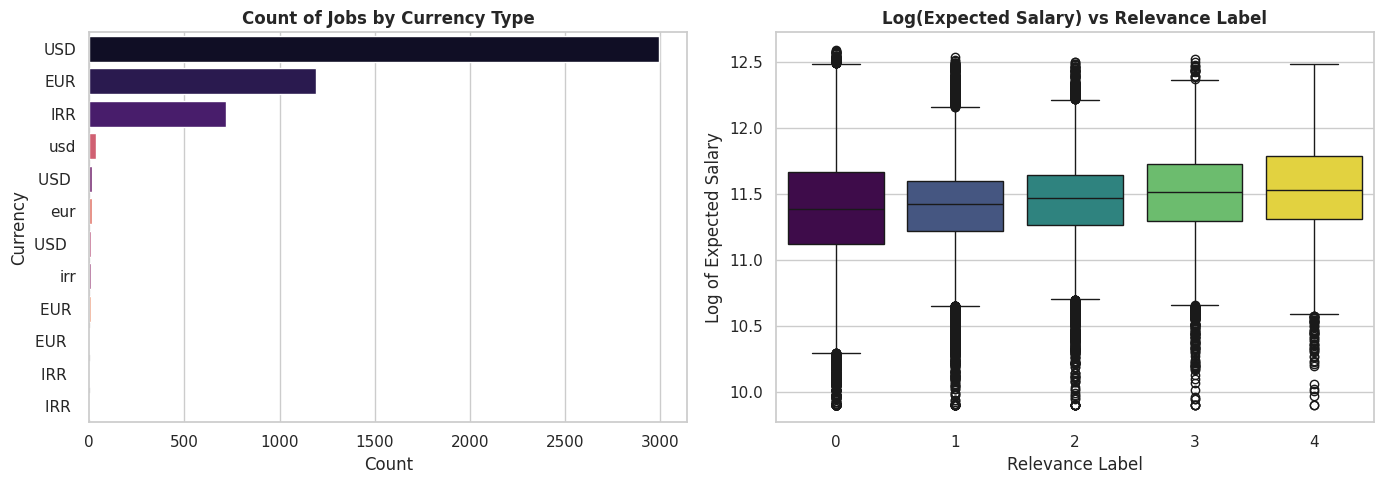


--- Sample of Job Locations vs Candidate Locations ---
Job Locations (Unique): <StringArray>
[      'Toronto',     'Amsterdam',        'Boston',        'Munich',
 'San Francisco',        'Tabriz',       'Mashhad',        'Shiraz',
        'Tehran',         'Tokyo']
Length: 10, dtype: str
Candidate Locations (Unique): <StringArray>
[   'Shiraz',   'Isfahan',   'Toronto',    'Remote',  'Istanbul',    'Berlin',
    'Munich',    'tehran',   'Seattle', 'Vancouver']
Length: 10, dtype: str


In [48]:
# 1. Inspecting the Salary Currencies in Jobs
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.countplot(y='salary_currency', data=jobs_df, order=jobs_df['salary_currency'].value_counts().index, hue='salary_currency', palette='magma', legend=False)
plt.title('Count of Jobs by Currency Type', fontweight='bold')
plt.xlabel('Count')
plt.ylabel('Currency')

# 2. Inspecting the distribution of Expected Salary across Relevance Labels
# We apply a log scale because IRR (Rial) values will severely distort the plot
plt.subplot(1, 2, 2)
eda_df['log_expected_salary'] = np.log1p(eda_df['expected_salary'])
sns.boxplot(x='relevance_label', y='log_expected_salary', data=eda_df, hue='relevance_label', palette='viridis', legend=False)
plt.title('Log(Expected Salary) vs Relevance Label', fontweight='bold')
plt.xlabel('Relevance Label')
plt.ylabel('Log of Expected Salary')

plt.tight_layout()
plt.savefig('latex/assets/images/02_currency_and_salary.png', bbox_inches='tight', dpi=300)
plt.show()

# 3. Quick check of location string inconsistencies
print("\n--- Sample of Job Locations vs Candidate Locations ---")
print("Job Locations (Unique):", jobs_df['job_location'].unique()[:10])
print("Candidate Locations (Unique):", candidates_df['candidate_location'].unique()[:10])

### High Cardinality Check (Justifying OOF Target Encoding)

In [49]:
# --- High Cardinality Check ---
print("\n--- Categorical Cardinality (Unique Values) ---")
print(f"Unique Job Titles: {jobs_df['job_title'].nunique()}")
print(f"Unique Candidate Titles: {candidates_df['current_title'].nunique()}")
print(f"Unique Universities: {candidates_df['university'].nunique()}")
print(f"Unique Companies: {candidates_df['previous_companies'].nunique()}")


--- Categorical Cardinality (Unique Values) ---
Unique Job Titles: 180
Unique Candidate Titles: 200
Unique Universities: 142
Unique Companies: 28238


### Temporal Distribution (Justifying the Validation Split)

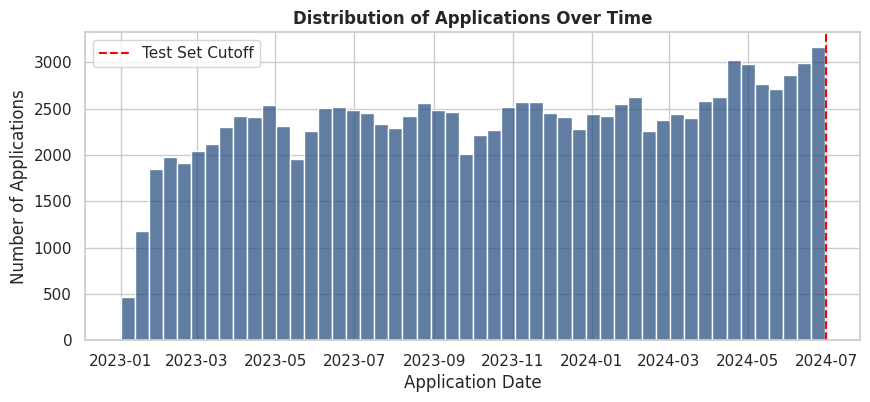

In [50]:
# --- Temporal Distribution Check ---
# Convert date to datetime object
train_df['application_date'] = pd.to_datetime(train_df['application_date'])

plt.figure(figsize=(10, 4))
sns.histplot(data=train_df, x='application_date', bins=50, color='#2c5282')
plt.title('Distribution of Applications Over Time', fontweight='bold')
plt.xlabel('Application Date')
plt.ylabel('Number of Applications')
plt.axvline(pd.to_datetime('2024-07-01'), color='red', linestyle='--', label='Test Set Cutoff')
plt.legend()
plt.savefig('latex/assets/images/03_temporal_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

### Interaction Proxy: The Experience Gap (Justifying Engineered Features)

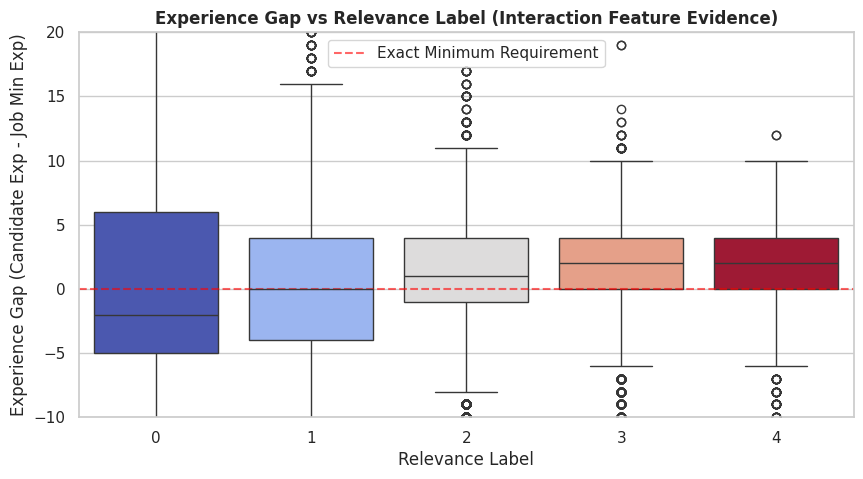

In [51]:
# --- Feature Interaction Evidence: Experience Gap ---
# Calculate the raw difference in experience
eda_df['experience_gap'] = eda_df['years_experience'] - eda_df['min_years_experience']

plt.figure(figsize=(10, 5))
# Limit the x-axis to remove crazy outliers for the plot
sns.boxplot(x='relevance_label', y='experience_gap', data=eda_df, hue='relevance_label', palette='coolwarm', legend=False)
plt.ylim(-10, 20) 
plt.title('Experience Gap vs Relevance Label (Interaction Feature Evidence)', fontweight='bold')
plt.xlabel('Relevance Label')
plt.ylabel('Experience Gap (Candidate Exp - Job Min Exp)')
plt.axhline(0, color='red', linestyle='--', alpha=0.6, label='Exact Minimum Requirement')
plt.legend()
plt.savefig('latex/assets/images/04_experience_gap_proxy.png', bbox_inches='tight', dpi=300)
plt.show()

<a id="preprocessing"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">2. Preprocessing & Feature Engineering</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> In this section, we merge the relational tables and construct our interaction features. To handle historical currency volatility (e.g., IRR inflation), the currency normalizer is parameterized. This allows the exchange rate to be dynamically treated as a hyperparameter and optimized via cross-validation later in the pipeline. Out-of-Fold (OOF) Target Encoding is utilized to safely encode categorical fields.
</div>

### Step 2.1: Data Integration & Text Standardization

In [52]:
# --- 2.1 Data Integration & Text Standardization ---

# 1. Merge the relational tables into unified Train and Test DataFrames
train_full = train_df.merge(jobs_df, on='job_id', how='left').merge(candidates_df, on='candidate_id', how='left')
test_full = test_df.merge(jobs_df, on='job_id', how='left').merge(candidates_df, on='candidate_id', how='left')

# 2. Text Standardization Function
def standardize_text(df, columns):
    for col in columns:
        if col in df.columns:
            # Lowercase, strip whitespace, and fill missing with 'none'
            df[col] = df[col].astype(str).str.lower().str.strip()
            df[col] = df[col].replace(['nan', 'none', ''], 'none')
    return df

text_columns_to_clean = [
    'job_location', 'candidate_location', 'current_title', 'job_title', 
    'education_level', 'university', 'salary_currency', 'willing_to_relocate', 'remote_allowed'
]

train_full = standardize_text(train_full, text_columns_to_clean)
test_full = standardize_text(test_full, text_columns_to_clean)

# 3. Handle Missing Numerical Values
# Fill missing max experience with the median of the minimum experience + 5 years as a proxy
for df in [train_full, test_full]:
    df['max_years_experience'] = df['max_years_experience'].fillna(df['min_years_experience'] + 5)
    df['years_experience'] = df['years_experience'].fillna(0)

print(f"Standardized Train Shape: {train_full.shape}")
print(f"Standardized Test Shape: {test_full.shape}")

Standardized Train Shape: (118772, 30)
Standardized Test Shape: (52700, 29)


### Step 2.2 Dynamic Currency Normalizer

In [53]:
# --- 2.2 Dynamic Currency Normalization (UPDATED) ---

def normalize_currency(df, eur_rate=1.08, irr_rate=0.00002):
    df_out = df.copy()
    
    exchange_rates = {'usd': 1.0, 'eur': eur_rate, 'irr': irr_rate}
    
    # Only map the rates to the JOB salaries
    rates = df_out['salary_currency'].map(exchange_rates).fillna(1.0)
    
    df_out['salary_min_usd'] = df_out['salary_min'] * rates
    df_out['salary_max_usd'] = df_out['salary_max'] * rates
    
    # The candidate's expected salary is ALREADY in USD. Leave it alone!
    df_out['expected_salary_usd'] = df_out['expected_salary'].fillna(0)
    
    return df_out

train_full = normalize_currency(train_full)
test_full = normalize_currency(test_full)

# Display a sample to verify the math on the currency bug fix
print("Dynamic Currency Normalization Complete. Sample USD values:")
display(train_full[['salary_currency', 'salary_max', 'salary_max_usd', 'expected_salary_usd']].head(3))

Dynamic Currency Normalization Complete. Sample USD values:


,salary_currency,salary_max,salary_max_usd,expected_salary_usd
0,irr,3630000000,72600.0,116655.275330
1,irr,3630000000,72600.0,86966.039783
2,irr,3630000000,72600.0,91955.832040


### Step 2.3 Interaction Features

In [54]:
# --- 2.3 Feature Engineering: 8 Interaction Features (UPDATED) ---

def calculate_jaccard(skills_a, skills_b):
    if pd.isna(skills_a) or pd.isna(skills_b) or skills_a == 'none' or skills_b == 'none': return 0.0
    set_a = set([s.strip().lower() for s in skills_a.split('|')])
    set_b = set([s.strip().lower() for s in skills_b.split('|')])
    if not set_a or not set_b: return 0.0
    return len(set_a.intersection(set_b)) / len(set_a.union(set_b))

def extract_seniority(title):
    title = str(title).lower()
    if any(w in title for w in ['senior', 'sr', 'principal', 'lead', 'director', 'cto']): return 3
    if 'mid' in title: return 2
    if any(w in title for w in ['junior', 'jr', 'intern']): return 1
    return 0 # Unspecified

def map_english(prof):
    mapping = {'a1':1, 'a2':2, 'b1':3, 'intermediate':3, 'b2':4, 'upper-intermediate':4, 'c1':5, 'advanced':5, 'c2':6, 'fluent':6, 'native':7}
    return mapping.get(str(prof).lower().strip(), 0)

def build_interactions(df):
    df_out = df.copy()
    
    # 1. Skill Overlap (Jaccard)
    df_out['skill_overlap_score'] = df_out.apply(lambda x: calculate_jaccard(x['skills'], x['required_skills']), axis=1)
    
    # 2. Experience Gap
    df_out['experience_gap'] = df_out['years_experience'] - df_out['min_years_experience']
    
    # 3. Salary Mismatch Flag
    df_out['salary_within_budget'] = (df_out['expected_salary_usd'] <= df_out['salary_max_usd']).astype(int)
    
    # 4. Education Compatibility 
    edu_map = {'none': 0, 'bachelor': 1, 'master': 2, 'phd': 3}
    df_out['education_score'] = df_out['education_level'].map(edu_map).fillna(0)
    
    # 5. Location Compatibility
    df_out['location_match'] = ((df_out['candidate_location'] == df_out['job_location']) | (df_out['remote_allowed'] == 'yes') | (df_out['willing_to_relocate'] == 'yes')).astype(int)
    
    # --- NEW FEATURES ---
    # 6. Skill Count Ratio (Candidate total skills / Job required skills)
    df_out['cand_skill_count'] = df_out['skills'].apply(lambda x: len(str(x).split('|')) if x != 'none' else 0)
    df_out['job_skill_count'] = df_out['required_skills'].apply(lambda x: len(str(x).split('|')) if x != 'none' else 0)
    df_out['skill_count_ratio'] = np.where(df_out['job_skill_count'] > 0, df_out['cand_skill_count'] / df_out['job_skill_count'], 0)
    
    # 7. Seniority Match
    df_out['cand_seniority'] = df_out['current_title'].apply(extract_seniority)
    df_out['job_seniority'] = df_out['job_title'].apply(extract_seniority)
    df_out['seniority_match'] = (df_out['cand_seniority'] >= df_out['job_seniority']).astype(int)
    
    # 8. English Proficiency Score
    df_out['english_score'] = df_out['english_proficiency'].apply(map_english)
    
    return df_out

train_full = build_interactions(train_full)
test_full = build_interactions(test_full)

# Verify all 8 new interaction features populated correctly
print("Engineered 8 Interaction Features Successfully!")
display(train_full[['skill_overlap_score', 'experience_gap', 'salary_within_budget', 'education_score', 
                    'location_match', 'skill_count_ratio', 'seniority_match', 'english_score']].head(3))

Engineered 8 Interaction Features Successfully!


,skill_overlap_score,experience_gap,salary_within_budget,education_score,location_match,skill_count_ratio,seniority_match,english_score
0,0.071429,4.0,0,2.0,0,2.0,1,0
1,0.000000,1.0,0,3.0,0,1.8,1,5
2,0.333333,-2.0,0,1.0,0,1.4,1,3


### Step 2.4: Out-of-Fold (OOF) Target Encoding

In [55]:
# --- 2.4 Out-of-Fold (OOF) Target Encoding (UPDATED for Tuning) ---
from sklearn.model_selection import GroupKFold

def apply_oof_encoding(train_df, test_df, encoded_feature='current_title', target_col='relevance_label', n_splits=5, smoothing=10):
    new_col_name = f'oof_{encoded_feature}_encoded'
    
    # Working copies
    train_out = train_df.copy()
    test_out = test_df.copy()
    train_out[new_col_name] = np.nan
    
    global_mean = train_out[target_col].mean()
    gkf = GroupKFold(n_splits=n_splits)
    
    # 1. Map to Train (OOF) with Smoothing
    for train_idx, val_idx in gkf.split(train_out, groups=train_out['job_id']):
        X_train_fold = train_out.iloc[train_idx]
        
        # Calculate stats for smoothing: (Count * Mean + Smoothing * Global_Mean) / (Count + Smoothing)
        stats = X_train_fold.groupby(encoded_feature)[target_col].agg(['count', 'mean'])
        smoothed_means = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
        
        train_out.loc[val_idx, new_col_name] = train_out.loc[val_idx, encoded_feature].map(smoothed_means)

    train_out[new_col_name] = train_out[new_col_name].fillna(global_mean)
    
    # 2. Map to Test using full train data stats
    full_stats = train_out.groupby(encoded_feature)[target_col].agg(['count', 'mean'])
    full_smoothed = (full_stats['count'] * full_stats['mean'] + smoothing * global_mean) / (full_stats['count'] + smoothing)
    test_out[new_col_name] = test_out[encoded_feature].map(full_smoothed).fillna(global_mean)
    
    return train_out, test_out

# Execute the function
train_full, test_full = apply_oof_encoding(train_full, test_full, encoded_feature='current_title', n_splits=5, smoothing=10)

# Verify the smoothed mathematical mapping of the titles
print("OOF Target Encoding Applied Safely Without Leakage!")
display(train_full[['current_title', 'oof_current_title_encoded', 'relevance_label']].head(4))

OOF Target Encoding Applied Safely Without Leakage!


,current_title,oof_current_title_encoded,relevance_label
0,senior devops engineer,1.143448,2
1,web developer,1.292634,1
2,backend developer,1.218027,2
3,frontend developer,1.243244,1


<a id="modeling"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">3. Model Development & Selection</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> We implement specialized point-wise or pair-wise ranking algorithms using traditional machine learning frameworks (e.g., LightGBM). The data is grouped by <code>job_id</code> during training to optimize the model specifically for the Information Retrieval task of relative ordering.
</div>

##

### Step 3.1: Temporal Validation Split

In [56]:
# --- 3.1 Temporal Validation Split ---

# Ensure datetime format
train_full['application_date'] = pd.to_datetime(train_full['application_date'])

# Set cutoff date for local validation (last 2 months of training data)
cutoff_date = pd.to_datetime('2024-05-01')

train_set = train_full[train_full['application_date'] < cutoff_date].copy()
val_set = train_full[train_full['application_date'] >= cutoff_date].copy()

print(f"Total Training Applications: {train_set.shape[0]}")
print(f"Total Validation Applications: {val_set.shape[0]}")

Total Training Applications: 102622
Total Validation Applications: 16150


### Step 3.2: Query Group Structuring (Critical for LTR)

In [57]:
# --- 3.2 Query Group Structuring ---

# 1. Sort the datasets by job_id (MANDATORY FOR RANKERS)
train_set = train_set.sort_values('job_id')
val_set = val_set.sort_values('job_id')

# 2. Extract group sizes (e.g., Job A has 15 applicants, Job B has 8)
train_groups = train_set.groupby('job_id').size().to_numpy()
val_groups = val_set.groupby('job_id').size().to_numpy()

# 3. Define the features we want the model to learn from (Exclude strings and IDs)
cols_to_drop = [
    'application_id', 'candidate_id', 'job_id', 'application_date', 'relevance_label',
    'job_title', 'required_skills', 'salary_currency', 'job_location', 'remote_allowed', 'industry',
    'current_title', 'skills', 'education_level', 'university', 'previous_companies', 'certifications',
    'english_proficiency', 'candidate_location', 'willing_to_relocate', 'account_created_date',
    'job_posted_date', 'company_size' # <-- FIXED: Added the string columns causing the crash
]

# Keep only engineered numerical features
features = [c for c in train_full.columns if c not in cols_to_drop]

# 4. Prepare X and y matrices
X_train, y_train = train_set[features], train_set['relevance_label']
X_val, y_val = val_set[features], val_set['relevance_label']

print(f"Features used for training ({len(features)} total): {features}")
print(f"\nSample Train Groups Array: {train_groups[:5]}")

Features used for training (23 total): ['min_years_experience', 'max_years_experience', 'salary_min', 'salary_max', 'years_experience', 'expected_salary', 'profile_completeness', 'salary_min_usd', 'salary_max_usd', 'expected_salary_usd', 'skill_overlap_score', 'experience_gap', 'salary_within_budget', 'education_score', 'location_match', 'cand_skill_count', 'job_skill_count', 'skill_count_ratio', 'cand_seniority', 'job_seniority', 'seniority_match', 'english_score', 'oof_current_title_encoded']

Sample Train Groups Array: [16 23 33 22 20]


### Step 3.3: Training the Specialized Ranker

In [58]:
# --- 3.3 Pipeline Hyperparameter Tuning (WARNING FIXED) ---
import lightgbm as lgb
import pandas as pd

# Set up our temporal cutoff
cutoff_date = pd.to_datetime('2024-05-01')

# Parameters to test
irr_rates_to_test = [0.00002, 0.000015] 
smoothing_to_test = [5, 10, 20]         

best_score = 0
best_params = {}

print("Starting Preprocessing & Hyperparameter Tuning Loop...\n")

for irr in irr_rates_to_test:
    for sm in smoothing_to_test:
        print(f"Testing IRR Rate: {irr} | OOF Smoothing: {sm}")
        
        # 1. Dynamically apply our Phase 2 functions
        temp_train = normalize_currency(train_full, irr_rate=irr)
        temp_train = build_interactions(temp_train)
        temp_train, _ = apply_oof_encoding(temp_train, test_full, smoothing=sm)
        
        # 2. Temporal Split
        temp_train['application_date'] = pd.to_datetime(temp_train['application_date'])
        t_set = temp_train[temp_train['application_date'] < cutoff_date].sort_values('job_id')
        v_set = temp_train[temp_train['application_date'] >= cutoff_date].sort_values('job_id')
        
        # 3. Extract LTR Groups & Matrices
        t_groups = t_set.groupby('job_id').size().to_numpy()
        v_groups = v_set.groupby('job_id').size().to_numpy()
        X_t, y_t = t_set[features], t_set['relevance_label']
        X_v, y_v = v_set[features], v_set['relevance_label']
        
        # 4. Train the Ranker (eval_at removed from here)
        ranker = lgb.LGBMRanker(
            objective="lambdarank", metric="ndcg", 
            learning_rate=0.05, n_estimators=300, min_child_samples=50, random_state=42,
            verbosity=-1 
        )
        
        # eval_at added here to fix the warning
        ranker.fit(
            X=X_t, y=y_t, group=t_groups, 
            eval_set=[(X_v, y_v)], eval_group=[v_groups], eval_at=[10],
            callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
        )
        
        # 5. Record the Best Score
        current_score = ranker.best_score_['valid_0']['ndcg@10']
        print(f"--> Validation NDCG@10: {current_score:.4f}\n")
        
        if current_score > best_score:
            best_score = current_score
            best_params = {'irr_rate': irr, 'smoothing': sm}
            best_model = ranker

print("="*40)
print(f"Best Pipeline Found!")
print(f"Best Parameters: {best_params}")
print(f"Best NDCG@10 Score: {best_score:.4f}")

Starting Preprocessing & Hyperparameter Tuning Loop...

Testing IRR Rate: 2e-05 | OOF Smoothing: 5
--> Validation NDCG@10: 0.8676

Testing IRR Rate: 2e-05 | OOF Smoothing: 10
--> Validation NDCG@10: 0.8660

Testing IRR Rate: 2e-05 | OOF Smoothing: 20
--> Validation NDCG@10: 0.8659

Testing IRR Rate: 1.5e-05 | OOF Smoothing: 5
--> Validation NDCG@10: 0.8662

Testing IRR Rate: 1.5e-05 | OOF Smoothing: 10
--> Validation NDCG@10: 0.8651

Testing IRR Rate: 1.5e-05 | OOF Smoothing: 20
--> Validation NDCG@10: 0.8674

Best Pipeline Found!
Best Parameters: {'irr_rate': 2e-05, 'smoothing': 5}
Best NDCG@10 Score: 0.8676


### Step 3.4: Feature Importance Analysis

<Figure size 1000x600 with 0 Axes>

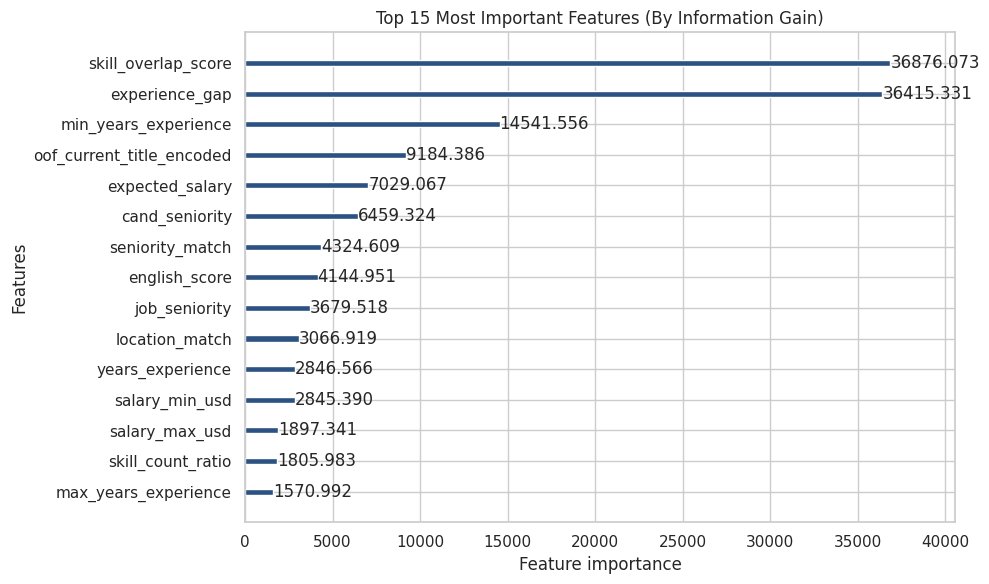

In [60]:
# --- 3.4 Feature Importance Analysis ---

plt.figure(figsize=(10, 6))
lgb.plot_importance(
    best_model, 
    max_num_features=15, 
    importance_type='gain', 
    title='Top 15 Most Important Features (By Information Gain)',
    color='#2c5282'
)
plt.tight_layout()
plt.savefig('latex/assets/images/05_feature_importance.png', bbox_inches='tight', dpi=300)
plt.show()

<a id="evaluation"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">4. Comprehensive Evaluation</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> In this section, we evaluate the model's ranking quality on the temporal validation set. To ensure mathematical transparency for the TA review, we implement custom evaluation functions for <strong>NDCG@10</strong> and <strong>AP@5</strong> based strictly on the Information Retrieval formulas (where relevance labels $\ge 3$ are considered binary hits for Average Precision). We calculate these metrics per <code>job_id</code> and aggregate them globally.
</div>

<a id="submission"></a>
<h2 style="color: #2c5282; border-bottom: 2px solid #cbd5e0; padding-bottom: 5px; margin-top: 40px;">5. Prediction & Final Submission</h2>

<div class="alert alert-warning" style="background-color: #fffaf0; border-left: 4px solid #dd6b20; color: #c05621;">
    <strong>⚙️ Methodology:</strong> The complete pipeline transforms the unseen test set to generate continuous relevance scores. The final predictions are saved directly into the submission format required by the Quera competition backend without altering the original row indices.
</div>

##